<a href="https://colab.research.google.com/github/diya687/varshi/blob/main/exp11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    Id Manufacturer    Model     Type  Min.Price  Price  Max.Price  MPG.city  \
0    1        Acura  Integra    Small       12.9   15.9       18.8        25   
1    2        Acura   Legend  Midsize       29.2   33.9       38.7        18   
2    3         Audi       90  Compact       25.9   29.1       32.3        20   
3    4         Audi      100  Midsize       30.8   37.7       44.6        19   
4    5          BMW     535i  Midsize       23.7   30.0       36.2        22   
..  ..          ...      ...      ...        ...    ...        ...       ...   
88  89   Volkswagen  Eurovan      Van       16.6   19.7       22.7        17   
89  90   Volkswagen   Passat  Compact       17.6   20.0       22.4        21   
90  91   Volkswagen  Corrado   Sporty       22.9   23.3       23.7        18   
91  92        Volvo      240  Compact       21.8   22.7       23.5        21   
92  93        Volvo      850  Midsize       24.8   26.7       28.5        20   

    MPG.highway             AirBags  ..

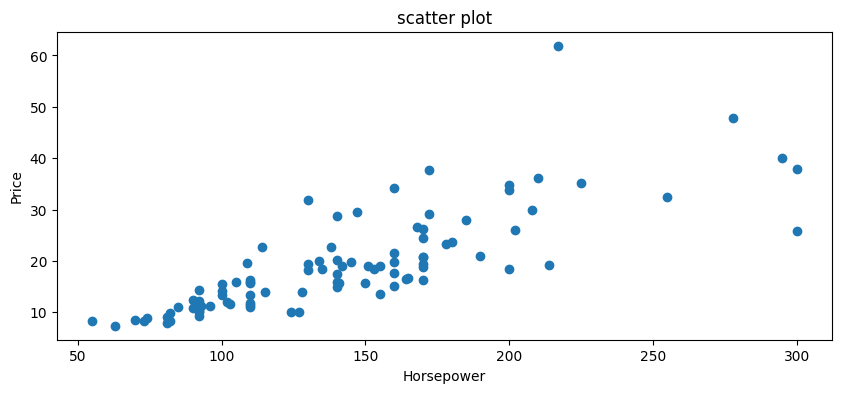

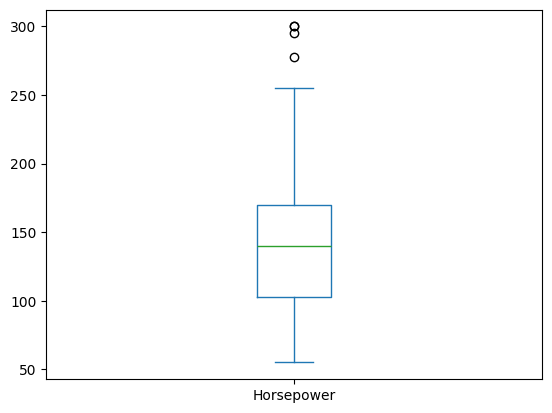

270.5
2.5
the following are the outliers in the boxplot of Horsepower:
 10    295
18    300
27    300
47    278
Name: Horsepower, dtype: int64


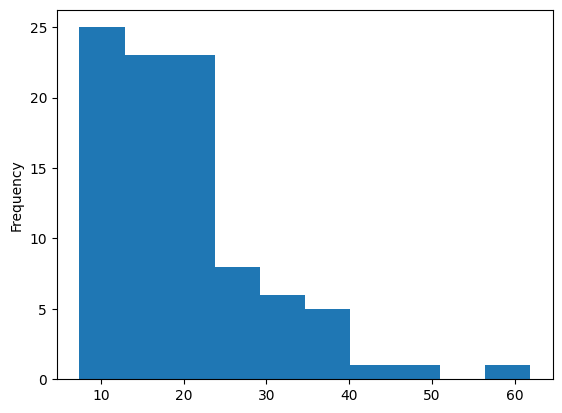

<class 'pandas.core.frame.DataFrame'>
Index: 89 entries, 0 to 92
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  89 non-null     int64  
 1   Manufacturer        89 non-null     object 
 2   Model               89 non-null     object 
 3   Type                89 non-null     object 
 4   Min.Price           89 non-null     float64
 5   Price               89 non-null     float64
 6   Max.Price           89 non-null     float64
 7   MPG.city            89 non-null     int64  
 8   MPG.highway         89 non-null     int64  
 9   AirBags             52 non-null     object 
 10  DriveTrain          89 non-null     object 
 11  Cylinders           89 non-null     object 
 12  EngineSize          89 non-null     float64
 13  Horsepower          89 non-null     int64  
 14  RPM                 89 non-null     int64  
 15  Rev.per.mile        89 non-null     int64  
 16  Man.trans.avail

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
car_df=pd.read_csv('/content/Cars93.csv')
print(car_df)
fig,ax=plt.subplots(figsize=(10,4))
ax.scatter(car_df['Horsepower'],car_df['Price'])
ax.set_xlabel('Horsepower')
ax.set_ylabel('Price')
plt.title("scatter plot")
plt.show()
car_df['Horsepower'].plot(kind='box')
plt.show()
q1=car_df['Horsepower'].quantile(0.25)
q3=car_df['Horsepower'].quantile(0.75)
iqr=q3-q1
upper_bound = q3+ (1.5*iqr)
lower_bound = q1- (1.5*iqr)
print(upper_bound)
print(lower_bound)
Horsepower_arr=car_df["Horsepower"]
outliers=Horsepower_arr[(Horsepower_arr <= lower_bound)|(Horsepower_arr >= upper_bound)]
print('the following are the outliers in the boxplot of Horsepower:\n',outliers)
car_df['Price'].plot(kind='hist')
plt.show()
upperIndex=car_df[car_df['Horsepower']>upper_bound].index
car_df.drop(upperIndex,inplace=True)
lowerIndex=car_df[car_df['Horsepower']<lower_bound].index
car_df.drop(lowerIndex,inplace=True)
print(car_df.info())
price_arr=car_df['Price']
upper_cap=np.percentile(price_arr,1)
lower_cap=np.percentile(price_arr,99)
outliers=price_arr[(price_arr<upper_cap)|(price_arr>=lower_cap)]
print('the following are the outliers in the boxplot of Price:\n',outliers)
for i in car_df['Price']:
  if i<lower_bound:
    car_df['Price']=car_df['Price'].replace(i,lower_cap)
  elif i>upper_bound:
    car_df['Price']=car_df['Price'].replace(i,upper_cap)
print(car_df.info())




